### Exploring the Titanic Dataset

Here’s your text formatted with Markdown for clarity and emphasis:

---

**What Are We Actually Trying to Learn?**

Notice that, at this stage, we're not yet asking *why* people survived.

We're simply **describing the target itself**:

- How many classes are there?
- How are they distributed?
- Are labels missing?
- Is the target categorical or numerical?
- Is the dataset balanced?

---
Only after understanding the target do we ask questions like:

- Did women survive more often?
- Did first-class passengers survive more?
- Did age influence survival?

Those questions move into **feature-to-target analysis** (sometimes called *bivariate analysis*), where you explore relationships between the target and the predictor variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the dataset
df = pd.read_csv('Titanic-Dataset.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
# check the information on available features in your dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df.shape

(891, 12)

In [5]:
df.describe() 

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# from locale import normalize


df['Survived'].value_counts()
df['Survived'].value_counts(normalize=True)*100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

### Handling Missing Values


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [8]:
# percentage missing per column
df.isnull().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [9]:
df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [10]:
## Fill the Embarked with Mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fill with median for Ages
df['Age'] = df['Age'].fillna(df['Age'].median())

In [13]:
df['Cabin'].unique()

# Those without cabin is an indication of lower class
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df.drop('Cabin', axis=1, inplace=True)

In [14]:
## No more missing values
df.sample(20)
# df.isnull().sum()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
712,713,1,1,"Taylor, Mr. Elmer Zebley",male,48.0,1,0,19996,52.0000,S,1
422,423,0,3,"Zimmerman, Mr. Leo",male,29.0,0,0,315082,7.8750,S,0
878,879,0,3,"Laleff, Mr. Kristo",male,28.0,0,0,349217,7.8958,S,0
349,350,0,3,"Dimic, Mr. Jovan",male,42.0,0,0,315088,8.6625,S,0
419,420,0,3,"Van Impe, Miss. Catharina",female,10.0,0,2,345773,24.1500,S,0
40,41,0,3,"Ahlin, Mrs. Johan (Johanna Persdotter Larsson)",female,40.0,1,0,7546,9.4750,S,0
646,647,0,3,"Cor, Mr. Liudevit",male,19.0,0,0,349231,7.8958,S,0
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,C,1
355,356,0,3,"Vanden Steen, Mr. Leo Peter",male,28.0,0,0,345783,9.5000,S,0
227,228,0,3,"Lovell, Mr. John Hall (""Henry"")",male,20.5,0,0,A/5 21173,7.2500,S,0


### Target Value Analysis
Why this matters: We always start with the target to understand the problem we're solving and identify strong predictors early.

Step 1: Identifying the Target

In the Kaggle Titanic competition, the dataset comes with a problem statement:

Predict which passengers survived the Titanic disaster.

Because the objective is explicitly stated, you immediately know that the target variable is:

Survived

where

`0 = Did not survive`
`1 = Survived`

In [15]:
# First you would want to know how many people survived and how many people didn't
df['Survived'].value_counts()

# Getting a percentage makes interpretation quiet easier
# Rougly 62% people died and 38% survived
df['Survived'].value_counts(normalize=True) * 100 

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
 11  Has_Cabin    891 non-null    int64  
dtypes: float64(2), int64(6), str(4)
memory usage: 83.7 KB


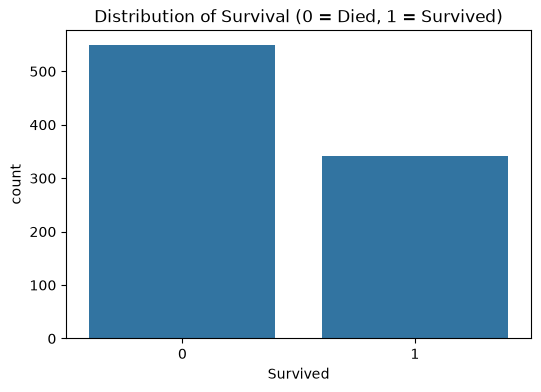

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Survived')
plt.title('Distribution of Survival (0 = Died, 1 = Survived)')
plt.show()

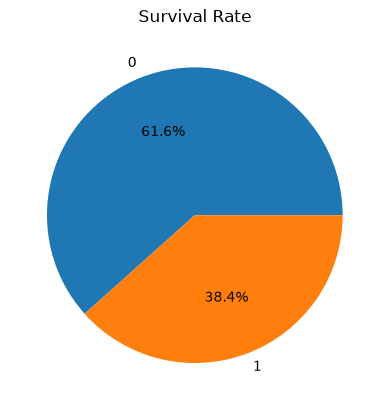

In [19]:
df['Survived'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Survival Rate')
plt.show()

Insight:

~62% died, ~38% survived (imbalanced classes).


#### Univariant Analysis

Univariate analysis is the simplest form of analyzing data. It deals with analyzing the distribution of a single variable.

In this section, we'll look at the distribution of the target variable and the predictor variables.



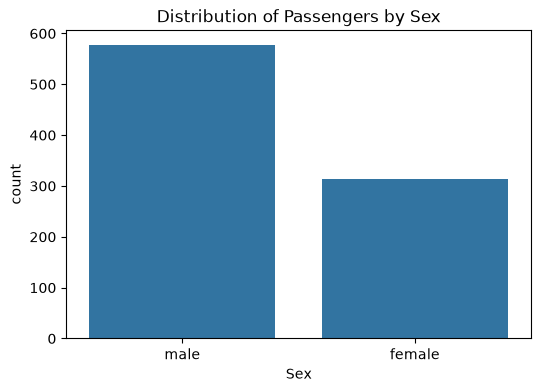

In [21]:
## comparing the genders on board
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sex')
plt.title('Distribution of Passengers by Sex')
plt.show()

`Insight: More males (~65%) than females (~35%).`

In [25]:
df['Pclass'].sample(30)
df['Pclass'].unique()

array([3, 1, 2])

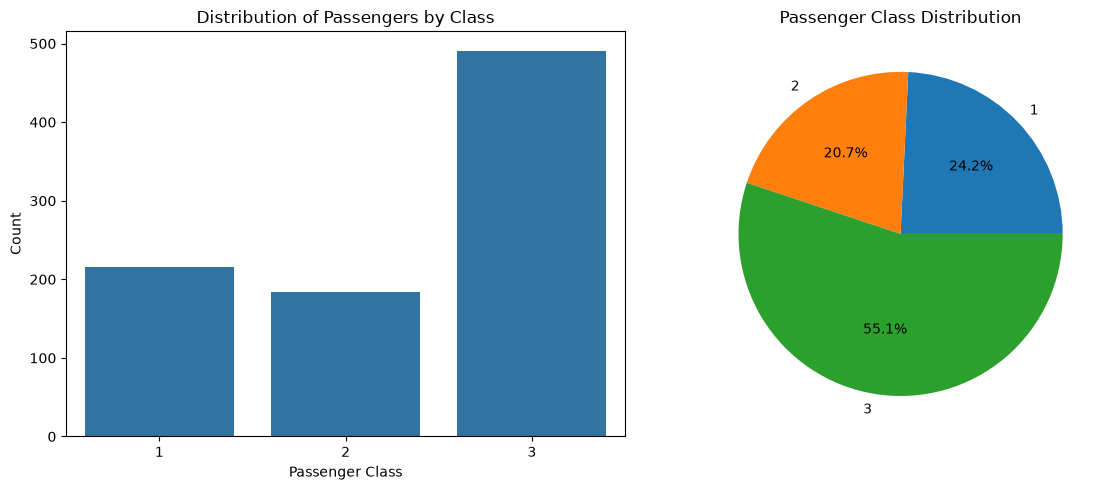

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df, x='Pclass', order=[1, 2, 3], ax=axes[0])
axes[0].set_title('Distribution of Passengers by Class')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Count')

# Pie chart
df['Pclass'].value_counts().sort_index().plot.pie(
    autopct='%1.1f%%',
    ax=axes[1]
)
axes[1].set_title('Passenger Class Distribution')
axes[1].set_ylabel('')  # Removes the default 'Pclass' label

plt.tight_layout()
plt.show()

`Insight: More first class passengers (~24%) than second class (~20%) or third class (~56%). Hence more passengers in the 3rd class.`







##### Numberical Variables

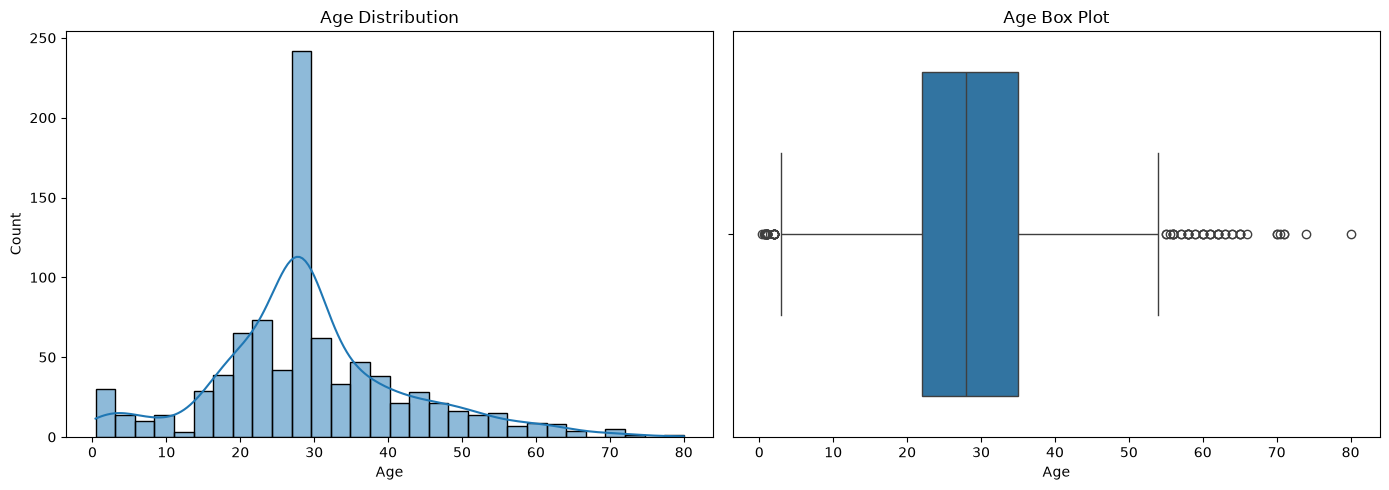

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(
    data=df,
    x='Age',
    kde=True,
    bins=30,
    ax=axes[0]
)
axes[0].set_title('Age Distribution')

# Box plot
sns.boxplot(
    data=df,
    x='Age',
    ax=axes[1]
)
axes[1].set_title('Age Box Plot')

plt.tight_layout()
plt.show()

`Insight`:

Right-skewed distribution (more younger passengers).
*Outliers*: A few passengers > 70 years old.

For Titanic ages, the KDE usually has:

a main peak around 20–30 years

a smaller bump for children

a long tail toward older ages (right skew)

##### FARE

In [33]:
df['Fare'].sample(20)

438    263.0000
135     15.0458
779    211.3375
383     52.0000
144     11.5000
469     19.2583
798      7.2292
46      15.5000
104      7.9250
248     52.5542
826     56.4958
102     77.2875
594     26.0000
597      0.0000
477      7.0458
390    120.0000
673     13.0000
99      26.0000
243      7.1250
833      7.8542
Name: Fare, dtype: float64

In [ ]:
df['Fare'].describe()

## Analysis
"""
Count: 891 - Every passenger has a fare value.
min: 0 - Why would someone pay nothing? -> Could be Crew? Complimentry ticket? Data entry issue?
max: 512.33 - The highest fare is much larger than expected. This is your first clue that there may be outliers.
mean: 32.20 - Why is the average more than twice the median? 
median: 14.45
                Possible explanation:
                Some passengers paid very large fares, pulling the average upward.
std: 49.69
                Another clue:
                Passengers paid vastly different ticket prices.
"""

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

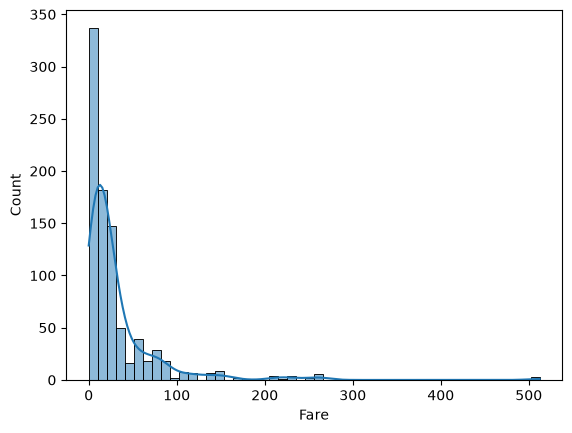

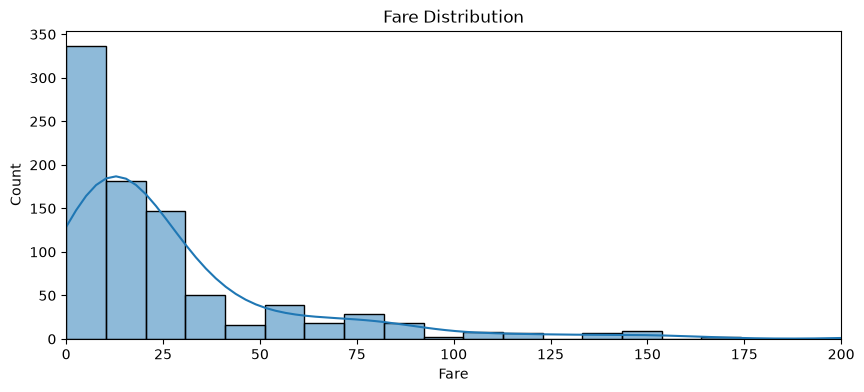

'\nNow you observe:\n\nHuge concentration near low fares.\nLong tail extending toward 500.\n\nYour hypothesis becomes stronger.\n\nThe distribution is right-skewed.\n'

In [37]:
#### Fare
sns.histplot(
    data=df,
    x='Fare',
    bins=50,
    kde=True
)

plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='Fare', kde=True, bins=50)
plt.title('Fare Distribution')
plt.xlim(0, 200)  # Zoom in (long tail due to extreme outliers)
plt.show()

"""
Now you observe:

Huge concentration near low fares.
Long tail extending toward 500.

Your hypothesis becomes stronger.

The distribution is right-skewed.
"""

<Axes: xlabel='Fare'>

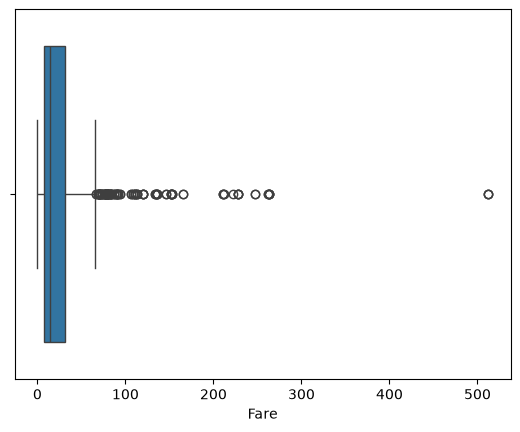

In [38]:
### Comfirm outliers with a Boxplot
sns.boxplot(x=df['Fare'])